In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

from functions import clean, split_data, evaluate_predictions

In [2]:
# load data
MRSA_df = pd.read_csv("MRSA_synthetic.csv")
VRE_df = pd.read_csv("VRE_synthetic.csv")
CRE_df = pd.read_csv("CRE_synthetic.csv")

In [3]:
# join data
joined_df = pd.concat([MRSA_df, VRE_df, CRE_df], ignore_index=True)

# add clean text
joined_df["text_clean"] = joined_df["clinical_report"].apply(clean)

In [4]:
# standardise labels and target columns
joined_df["label"] = joined_df["label"].fillna("NONE").astype(str).str.strip().str.upper()
joined_df["organism"] = joined_df["organism"].fillna("UNKNOWN").astype(str).str.strip().str.upper()
joined_df["antibiotic"] = joined_df["antibiotic"].fillna("UNKNOWN").astype(str).str.strip().str.upper()
joined_df["susceptibility"] = joined_df["susceptibility"].fillna("UNKNOWN").astype(str).str.strip().str.upper()

joined_df["clinical_report"] = joined_df["clinical_report"].fillna("").astype(str)
joined_df["text_clean"] = joined_df["text_clean"].fillna("").astype(str)

In [5]:
# collapse negative labels into one class
joined_df["label"] = joined_df["label"].replace({
    "NOT_MRSA": "NONE",
    "NOT_VRE": "NONE",
    "NOT_CRE": "NONE"
})

In [6]:
# check labels
print("Label values:")
print(joined_df["label"].value_counts())

Label values:
label
NONE    700
MRSA    500
VRE     100
CRE     100
Name: count, dtype: int64


In [7]:
# split data
joined_train, joined_test = split_data(joined_df, label_col="label")

print("Train:", len(joined_train), "Test:", len(joined_test))
print("\nTrain label distribution:")
print(joined_train["label"].value_counts())

Train: 1120 Test: 280

Train label distribution:
label
NONE    560
MRSA    400
VRE      80
CRE      80
Name: count, dtype: int64


In [8]:
# define target columns
target_columns = ["organism", "antibiotic", "susceptibility", "label"]

# define train/test inputs
X_train = joined_train["text_clean"]
y_train = joined_train[target_columns]

X_test = joined_test["text_clean"]
y_test = joined_test[target_columns]

In [9]:
# joint logistic regression model

joint_logreg_model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
    ("clf", MultiOutputClassifier(LogisticRegression(max_iter=2000)))
])

joint_logreg_model.fit(X_train, y_train)
joint_logreg_preds = joint_logreg_model.predict(X_test)

joined_test["pred_org_joint_logreg"] = joint_logreg_preds[:, 0]
joined_test["pred_abx_joint_logreg"] = joint_logreg_preds[:, 1]
joined_test["pred_sus_joint_logreg"] = joint_logreg_preds[:, 2]
joined_test["pred_label_joint_logreg"] = joint_logreg_preds[:, 3]

Joint LogReg - Organism
Accuracy: 0.8607

Classification Report:
                                                                 precision    recall  f1-score   support

                                             CITROBACTER KOSERI       0.00      0.00      0.00         1
                                   COAG NEGATIVE STAPHYLOCOCCUS       0.98      0.98      0.98        44
                                        CORYNEBACTERIUM SPECIES       0.00      0.00      0.00         1
                                           ENTEROBACTER SPECIES       0.00      0.00      0.00         1
                                          ENTEROCOCCUS FAECALIS       1.00      0.57      0.73         7
                                           ENTEROCOCCUS FAECIUM       0.91      1.00      0.95        20
                                           ENTEROCOCCUS SPECIES       1.00      0.60      0.75         5
                                               ESCHERICHIA COLI       0.94      1.00      0.97

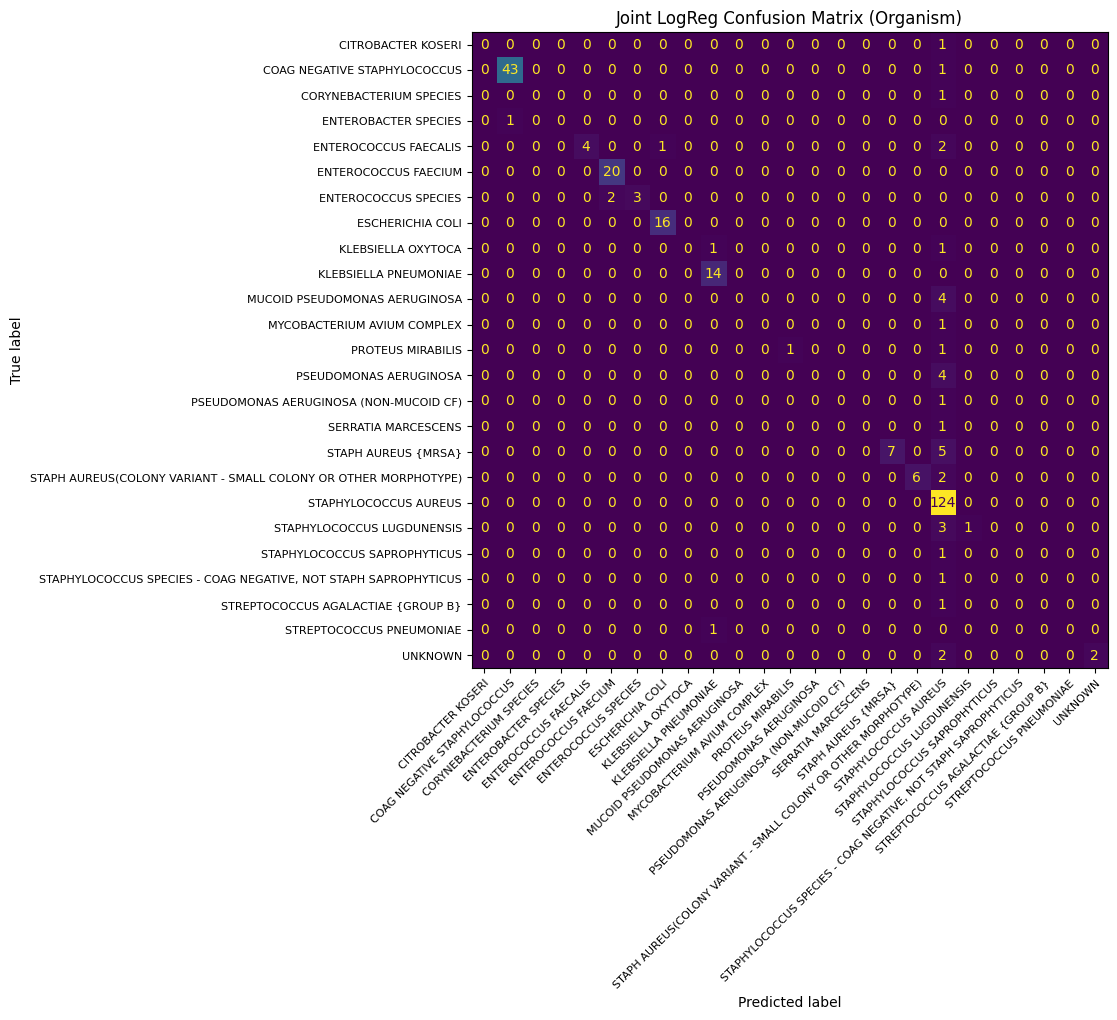


Number of errors: 39

First 10 error examples:
                                             text_clean  \
908   urine culture grew pseudomonas aeruginosa. cip...   
1146  urine culture positive for e. species. vancomy...   
722   staphylococcus aureus mrsa isolated. oxa resis...   
1333  susceptible. pneumoniae isolated from blood cx...   
681   msu positive for staphylococcus saprophyticus....   
1157  e. species grown consistent with . vancomycin ...   
1352  pseudomonas aeruginosa non-mucoid cf grown con...   
921   mycobacterium avium complex identified in sput...   
690   c.negativestaphylococcus identified in sputum ...   
1356  m. pseudomonas aeruginosa isolated imi non-sus...   

                                    organism  pred_org_joint_logreg  
908                   PSEUDOMONAS AERUGINOSA  STAPHYLOCOCCUS AUREUS  
1146                    ENTEROCOCCUS SPECIES   ENTEROCOCCUS FAECIUM  
722                      STAPH AUREUS {MRSA}  STAPHYLOCOCCUS AUREUS  
1333                ST

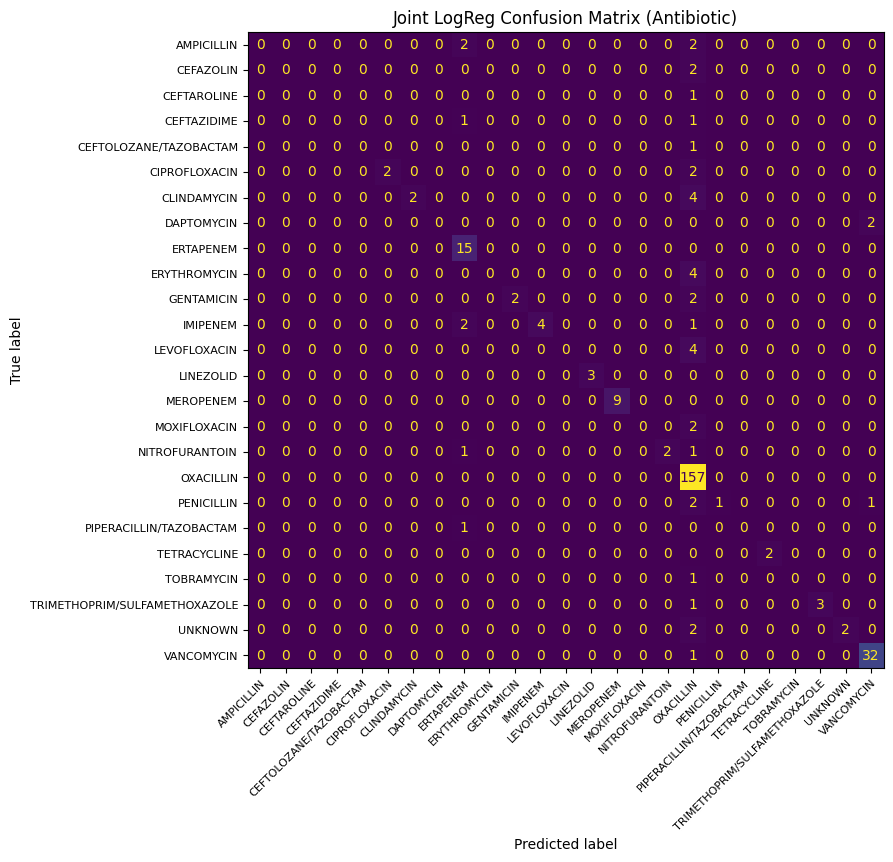


Number of errors: 44

First 10 error examples:
                                             text_clean  \
1263  growth of klebsiella pneumoniae imipenem non-s...   
1187  escherichia coli recovered. susceptibility amp...   
995   urine grew coliform presumptive escherichia co...   
944   e.species isolated from msu. ciprofloxacin int...   
921   mycobacterium avium complex identified in sput...   
999   klebsiella pneumoniae isolated from msu. tazoc...   
1252  msu klebsiella pneumoniae isolated. imipenem r...   
1164             growth of mrsa levofloxacin resistant.   
564   staphylococcus aureus cultured. gent reported ...   
528   staphylococcus aureus isolated possible pneumo...   

                   antibiotic pred_abx_joint_logreg  
1263                 IMIPENEM             ERTAPENEM  
1187               AMPICILLIN             ERTAPENEM  
995               CEFTAZIDIME             OXACILLIN  
944             CIPROFLOXACIN             OXACILLIN  
921              MOXIFLOXACIN   

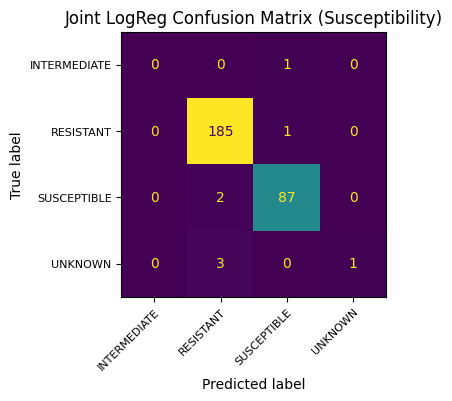


Number of errors: 7

First 7 error examples:
                                             text_clean susceptibility  \
944   e.species isolated from msu. ciprofloxacin int...   INTERMEDIATE   
509   methicillin resistant staphylococcus aureus gr...    SUSCEPTIBLE   
991                     isolated from sputum culture. .        UNKNOWN   
1168  urine grew susceptible. agalactiae group b . e...      RESISTANT   
901                             cultured. reported as .        UNKNOWN   
983             identified in catheter specimen urine .        UNKNOWN   
589   methicillin resistant staphylococcus aureus gr...    SUSCEPTIBLE   

     pred_sus_joint_logreg  
944            SUSCEPTIBLE  
509              RESISTANT  
991              RESISTANT  
1168           SUSCEPTIBLE  
901              RESISTANT  
983              RESISTANT  
589              RESISTANT  
Joint LogReg - Label
Accuracy: 0.9714

Classification Report:
              precision    recall  f1-score   support

         CRE

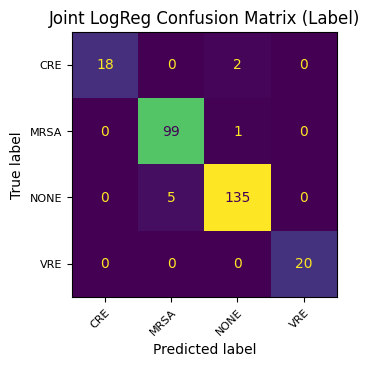


Number of errors: 8

First 8 error examples:
                                             text_clean label  \
722   staphylococcus aureus mrsa isolated. oxa resis...  NONE   
189   mrsa identified in tracheal aspirate meticilli...  MRSA   
509   methicillin resistant staphylococcus aureus gr...  NONE   
723   blood cultures grew staphylococcus lugdunensis...  NONE   
726   staphylococcus aureus mrsa isolated meticillin...  NONE   
1287  coliform presumptive escherichia coli isolated...   CRE   
1271   escherichia coli isolated. mero non-susceptible.   CRE   
589   methicillin resistant staphylococcus aureus gr...  NONE   

     pred_label_joint_logreg  
722                     MRSA  
189                     NONE  
509                     MRSA  
723                     MRSA  
726                     MRSA  
1287                    NONE  
1271                    NONE  
589                     MRSA  


In [10]:
#evaluation of logistic regression
joint_logreg_eval_results = []

#evaluate organism
joint_logreg_eval_results.append(
    evaluate_predictions(joined_test, "organism", "pred_org_joint_logreg", "text_clean", "Joint LogReg", "Organism")
)

#evaluate antibiotic
joint_logreg_eval_results.append(
    evaluate_predictions(joined_test, "antibiotic", "pred_abx_joint_logreg", "text_clean", "Joint LogReg", "Antibiotic")
)

#evaluate susceptibility
joint_logreg_eval_results.append(
    evaluate_predictions(joined_test, "susceptibility", "pred_sus_joint_logreg", "text_clean", "Joint LogReg", "Susceptibility")
)

#evaluate label
joint_logreg_eval_results.append(
    evaluate_predictions(joined_test, "label", "pred_label_joint_logreg", "text_clean", "Joint LogReg", "Label")
)


In [11]:
# joint support vector machine model

joint_svm_model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
    ("clf", MultiOutputClassifier(LinearSVC()))
])

joint_svm_model.fit(X_train, y_train)
joint_svm_preds = joint_svm_model.predict(X_test)

joined_test["pred_org_joint_svm"] = joint_svm_preds[:, 0]
joined_test["pred_abx_joint_svm"] = joint_svm_preds[:, 1]
joined_test["pred_sus_joint_svm"] = joint_svm_preds[:, 2]
joined_test["pred_label_joint_svm"] = joint_svm_preds[:, 3]

Joint SVM - Organism
Accuracy: 0.9607

Classification Report:
                                                                 precision    recall  f1-score   support

                                             CITROBACTER KOSERI       1.00      1.00      1.00         1
                                   COAG NEGATIVE STAPHYLOCOCCUS       1.00      1.00      1.00        44
                                        CORYNEBACTERIUM SPECIES       0.00      0.00      0.00         1
                                           ENTEROBACTER SPECIES       0.00      0.00      0.00         1
                                          ENTEROCOCCUS FAECALIS       1.00      1.00      1.00         7
                                           ENTEROCOCCUS FAECIUM       0.95      1.00      0.98        20
                                           ENTEROCOCCUS SPECIES       0.80      0.80      0.80         5
                                               ESCHERICHIA COLI       1.00      1.00      1.00   

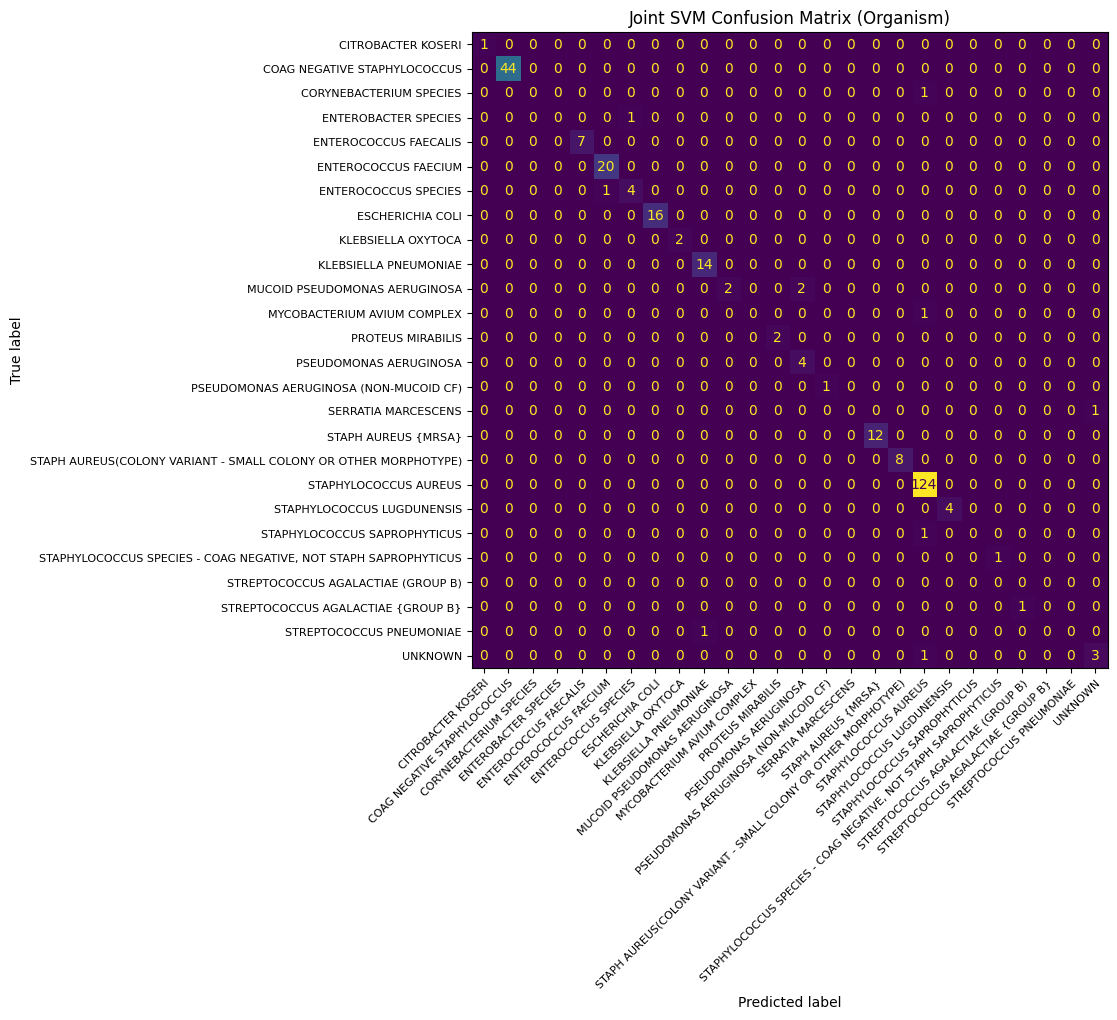


Number of errors: 11

First 10 error examples:
                                             text_clean  \
1333  susceptible. pneumoniae isolated from blood cx...   
681   msu positive for staphylococcus saprophyticus....   
1157  e. species grown consistent with . vancomycin ...   
921   mycobacterium avium complex identified in sput...   
1356  m. pseudomonas aeruginosa isolated imi non-sus...   
968   enterobacter species identified in blood cultu...   
975   growth of m. pseudomonas aeruginosa ceftolozan...   
940   susceptible.marcescens recovered. susceptibili...   
991                     isolated from sputum culture. .   
1168  urine grew susceptible. agalactiae group b . e...   

                                organism                  pred_org_joint_svm  
1333            STREPTOCOCCUS PNEUMONIAE               KLEBSIELLA PNEUMONIAE  
681         STAPHYLOCOCCUS SAPROPHYTICUS               STAPHYLOCOCCUS AUREUS  
1157                ENTEROCOCCUS SPECIES                ENTEROCOC

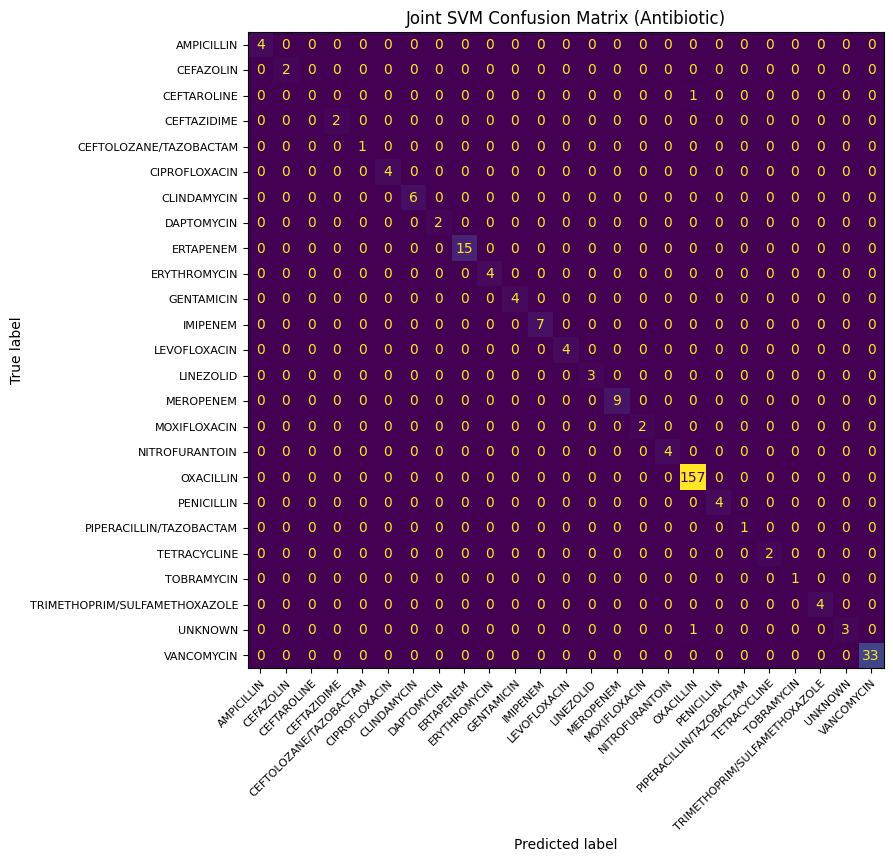


Number of errors: 2

First 2 error examples:
                                            text_clean   antibiotic  \
991                    isolated from sputum culture. .      UNKNOWN   
540  mrsa isolated bloodstream infection. ceftaroli...  CEFTAROLINE   

    pred_abx_joint_svm  
991          OXACILLIN  
540          OXACILLIN  
Joint SVM - Susceptibility
Accuracy: 0.9929

Classification Report:
              precision    recall  f1-score   support

INTERMEDIATE       1.00      1.00      1.00         1
   RESISTANT       0.99      1.00      0.99       186
 SUSCEPTIBLE       1.00      0.99      0.99        89
     UNKNOWN       1.00      0.75      0.86         4

    accuracy                           0.99       280
   macro avg       1.00      0.93      0.96       280
weighted avg       0.99      0.99      0.99       280



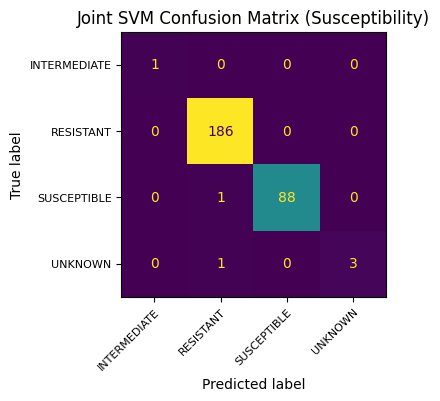


Number of errors: 2

First 2 error examples:
                                            text_clean susceptibility  \
991                    isolated from sputum culture. .        UNKNOWN   
589  methicillin resistant staphylococcus aureus gr...    SUSCEPTIBLE   

    pred_sus_joint_svm  
991          RESISTANT  
589          RESISTANT  
Joint SVM - Label
Accuracy: 0.9857

Classification Report:
              precision    recall  f1-score   support

         CRE       1.00      1.00      1.00        20
        MRSA       0.97      1.00      0.99       100
        NONE       1.00      0.97      0.99       140
         VRE       0.95      1.00      0.98        20

    accuracy                           0.99       280
   macro avg       0.98      0.99      0.99       280
weighted avg       0.99      0.99      0.99       280



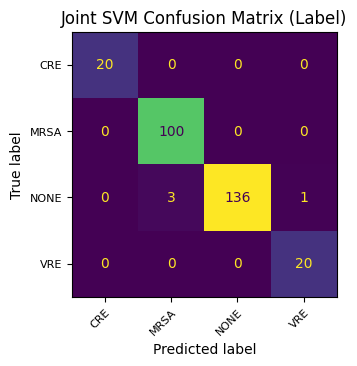


Number of errors: 4

First 4 error examples:
                                             text_clean label  \
1157  e. species grown consistent with . vancomycin ...  NONE   
509   methicillin resistant staphylococcus aureus gr...  NONE   
723   blood cultures grew staphylococcus lugdunensis...  NONE   
589   methicillin resistant staphylococcus aureus gr...  NONE   

     pred_label_joint_svm  
1157                  VRE  
509                  MRSA  
723                  MRSA  
589                  MRSA  


In [12]:
# evaluation of svm
joint_svm_eval_results = []

#evaluate organism
joint_svm_eval_results.append(
    evaluate_predictions(joined_test, "organism", "pred_org_joint_svm", "text_clean", "Joint SVM", "Organism")
)

#evaluate antibiotic
joint_svm_eval_results.append(
    evaluate_predictions(joined_test, "antibiotic", "pred_abx_joint_svm", "text_clean", "Joint SVM", "Antibiotic")
)
#evaluate susceptibility
joint_svm_eval_results.append(
    evaluate_predictions(joined_test, "susceptibility", "pred_sus_joint_svm", "text_clean", "Joint SVM", "Susceptibility")
)
#evaluate label
joint_svm_eval_results.append(
    evaluate_predictions(joined_test, "label", "pred_label_joint_svm", "text_clean", "Joint SVM", "Label")
)


In [13]:
# joint naive bayes model

joint_nb_model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
    ("clf", MultiOutputClassifier(MultinomialNB()))
])

joint_nb_model.fit(X_train, y_train)
joint_nb_preds = joint_nb_model.predict(X_test)

joined_test["pred_org_joint_nb"] = joint_nb_preds[:, 0]
joined_test["pred_abx_joint_nb"] = joint_nb_preds[:, 1]
joined_test["pred_sus_joint_nb"] = joint_nb_preds[:, 2]
joined_test["pred_label_joint_nb"] = joint_nb_preds[:, 3]

Joint NB - Organism
Accuracy: 0.7786

Classification Report:
                                                                 precision    recall  f1-score   support

                                             CITROBACTER KOSERI       0.00      0.00      0.00         1
                                   COAG NEGATIVE STAPHYLOCOCCUS       0.93      0.95      0.94        44
                                        CORYNEBACTERIUM SPECIES       0.00      0.00      0.00         1
                                           ENTEROBACTER SPECIES       0.00      0.00      0.00         1
                                          ENTEROCOCCUS FAECALIS       0.00      0.00      0.00         7
                                           ENTEROCOCCUS FAECIUM       0.78      0.90      0.84        20
                                           ENTEROCOCCUS SPECIES       0.00      0.00      0.00         5
                                               ESCHERICHIA COLI       0.84      1.00      0.91    

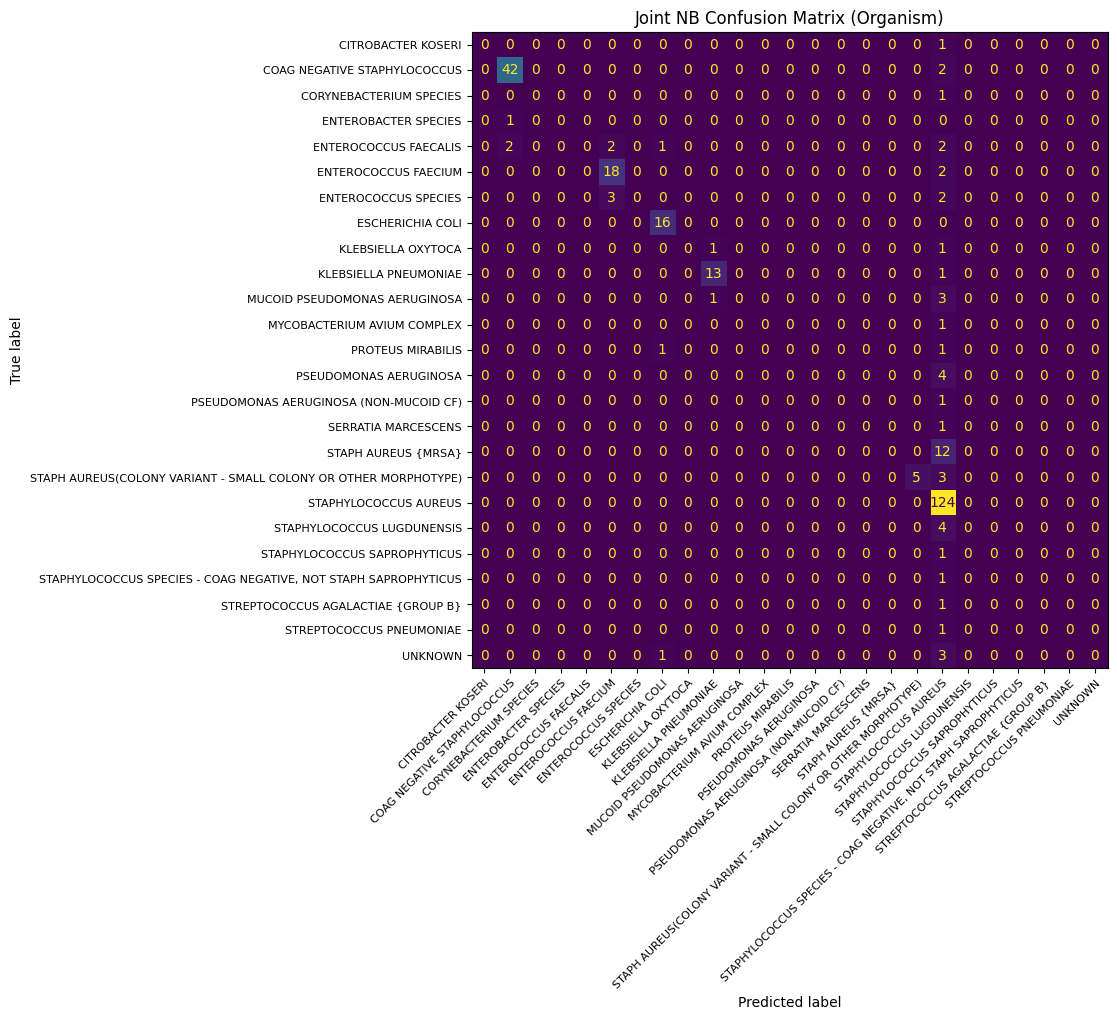


Number of errors: 62

First 10 error examples:
                                             text_clean  \
1155  enterococcus species identified in urine cultu...   
908   urine culture grew pseudomonas aeruginosa. cip...   
1146  urine culture positive for e. species. vancomy...   
732   susceptible.aureus mrsa isolated lrti. methici...   
722   staphylococcus aureus mrsa isolated. oxa resis...   
1337             growth of proteus mirabilis erta sens.   
1333  susceptible. pneumoniae isolated from blood cx...   
681   msu positive for staphylococcus saprophyticus....   
712   urine culture grew staphylococcus aureus mrsa ...   
1157  e. species grown consistent with . vancomycin ...   

                          organism      pred_org_joint_nb  
1155          ENTEROCOCCUS SPECIES   ENTEROCOCCUS FAECIUM  
908         PSEUDOMONAS AERUGINOSA  STAPHYLOCOCCUS AUREUS  
1146          ENTEROCOCCUS SPECIES   ENTEROCOCCUS FAECIUM  
732            STAPH AUREUS {MRSA}  STAPHYLOCOCCUS AUREUS  
72

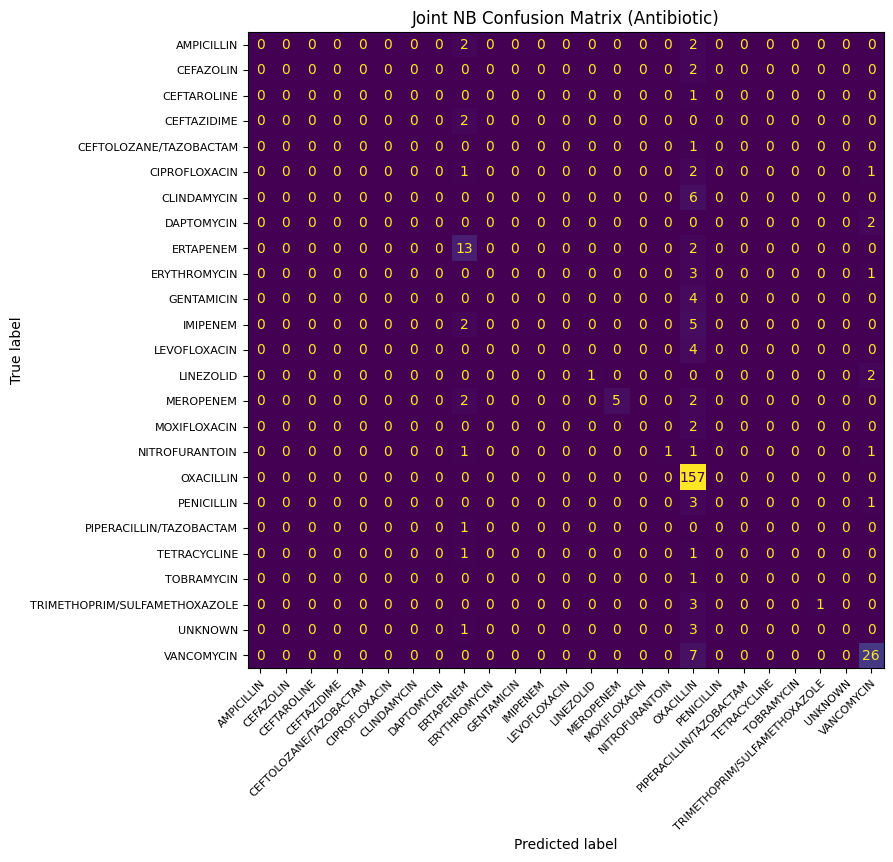


Number of errors: 76

First 10 error examples:
                                             text_clean     antibiotic  \
908   urine culture grew pseudomonas aeruginosa. cip...  CIPROFLOXACIN   
1263  growth of klebsiella pneumoniae imipenem non-s...       IMIPENEM   
1187  escherichia coli recovered. susceptibility amp...     AMPICILLIN   
1337             growth of proteus mirabilis erta sens.      ERTAPENEM   
1333  susceptible. pneumoniae isolated from blood cx...      MEROPENEM   
1303  escherichia coli isolated from catheter specim...  CIPROFLOXACIN   
995   urine grew coliform presumptive escherichia co...    CEFTAZIDIME   
944   e.species isolated from msu. ciprofloxacin int...  CIPROFLOXACIN   
507   susceptible.aureus identified in sputum cultur...     VANCOMYCIN   
1352  pseudomonas aeruginosa non-mucoid cf grown con...       IMIPENEM   

     pred_abx_joint_nb  
908          OXACILLIN  
1263         ERTAPENEM  
1187         ERTAPENEM  
1337         OXACILLIN  
1333        

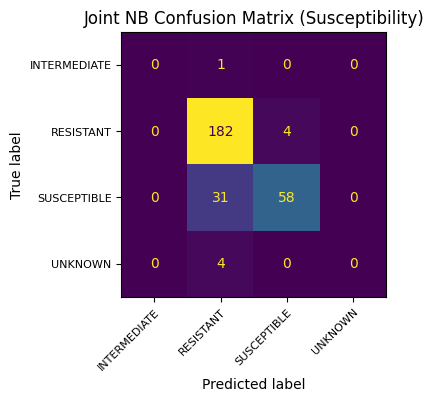


Number of errors: 40

First 10 error examples:
                                             text_clean susceptibility  \
838   c.negativestaphylococcus grown consistent with...    SUSCEPTIBLE   
1333  susceptible. pneumoniae isolated from blood cx...    SUSCEPTIBLE   
681   msu positive for staphylococcus saprophyticus....    SUSCEPTIBLE   
944   e.species isolated from msu. ciprofloxacin int...   INTERMEDIATE   
507   susceptible.aureus identified in sputum cultur...    SUSCEPTIBLE   
719   respiratory culture positive for susceptible. ...      RESISTANT   
999   klebsiella pneumoniae isolated from msu. tazoc...    SUSCEPTIBLE   
690   c.negativestaphylococcus identified in sputum ...    SUSCEPTIBLE   
650   c.negativestaphylococcus grown consistent with...    SUSCEPTIBLE   
564   staphylococcus aureus cultured. gent reported ...    SUSCEPTIBLE   

     pred_sus_joint_nb  
838          RESISTANT  
1333         RESISTANT  
681          RESISTANT  
944          RESISTANT  
507         

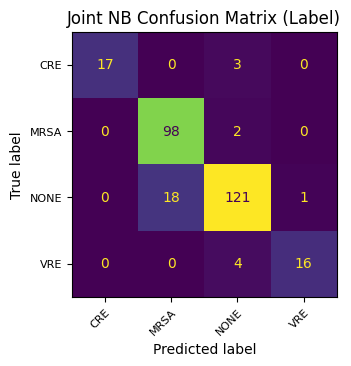


Number of errors: 28

First 10 error examples:
                                             text_clean label  \
1092  enterococcus faecium cultured. vancomycin repo...   VRE   
732   susceptible.aureus mrsa isolated lrti. methici...  NONE   
1263  growth of klebsiella pneumoniae imipenem non-s...   CRE   
722   staphylococcus aureus mrsa isolated. oxa resis...  NONE   
712   urine culture grew staphylococcus aureus mrsa ...  NONE   
1157  e. species grown consistent with . vancomycin ...  NONE   
1085  enterococcus faecium recovered. susceptibility...   VRE   
358   staphylococcus aureus isolated from peripheral...  MRSA   
702   susceptible. aureus mrsa identified in respira...  NONE   
504   et aspirate mrsa isolated. oxacillin susceptible.  NONE   

     pred_label_joint_nb  
1092                NONE  
732                 MRSA  
1263                NONE  
722                 MRSA  
712                 MRSA  
1157                 VRE  
1085                NONE  
358                 

In [14]:
# evaluate naive bayes
joint_nb_eval_results = []

#evaluate organism
joint_nb_eval_results.append(
    evaluate_predictions(joined_test, "organism", "pred_org_joint_nb", "text_clean", "Joint NB", "Organism")
)

#evaluate antibiotic
joint_nb_eval_results.append(
    evaluate_predictions(joined_test, "antibiotic", "pred_abx_joint_nb", "text_clean", "Joint NB", "Antibiotic")
)

#evaluate susceptibility
joint_nb_eval_results.append(
    evaluate_predictions(joined_test, "susceptibility", "pred_sus_joint_nb", "text_clean", "Joint NB", "Susceptibility")
)

#evaluate label
joint_nb_eval_results.append(
    evaluate_predictions(joined_test, "label", "pred_label_joint_nb", "text_clean", "Joint NB", "Label")
)


In [15]:
# combine evaluation results into one table
all_joint_eval_results = (
        joint_logreg_eval_results +
        joint_svm_eval_results +
        joint_nb_eval_results
)

all_joint_eval_df = pd.DataFrame(all_joint_eval_results)


# create metrics table for all models and tasks
metrics_results = []


def store_metrics_result(model_name, task_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    metrics_results.append({
        "Model": model_name,
        "Task": task_name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

#creating the table containing:

#Logistic regression evaluation metrics
store_metrics_result("Joint LogReg", "Organism", joined_test["organism"], joined_test["pred_org_joint_logreg"])
store_metrics_result("Joint LogReg", "Antibiotic", joined_test["antibiotic"], joined_test["pred_abx_joint_logreg"])
store_metrics_result("Joint LogReg", "Susceptibility", joined_test["susceptibility"],
                     joined_test["pred_sus_joint_logreg"])
store_metrics_result("Joint LogReg", "Label", joined_test["label"], joined_test["pred_label_joint_logreg"])

#Support Vector machine evaluation metrics
store_metrics_result("Joint SVM", "Organism", joined_test["organism"], joined_test["pred_org_joint_svm"])
store_metrics_result("Joint SVM", "Antibiotic", joined_test["antibiotic"], joined_test["pred_abx_joint_svm"])
store_metrics_result("Joint SVM", "Susceptibility", joined_test["susceptibility"], joined_test["pred_sus_joint_svm"])
store_metrics_result("Joint SVM", "Label", joined_test["label"], joined_test["pred_label_joint_svm"])

#Naive Bayes evaluation metrics
store_metrics_result("Joint NB", "Organism", joined_test["organism"], joined_test["pred_org_joint_nb"])
store_metrics_result("Joint NB", "Antibiotic", joined_test["antibiotic"], joined_test["pred_abx_joint_nb"])
store_metrics_result("Joint NB", "Susceptibility", joined_test["susceptibility"], joined_test["pred_sus_joint_nb"])
store_metrics_result("Joint NB", "Label", joined_test["label"], joined_test["pred_label_joint_nb"])


joint_results_df = pd.DataFrame(metrics_results).round(3)
print(joint_results_df)


           Model            Task  Accuracy  Precision  Recall     F1
0   Joint LogReg        Organism     0.861      0.816   0.861  0.822
1   Joint LogReg      Antibiotic     0.843      0.787   0.843  0.795
2   Joint LogReg  Susceptibility     0.975      0.972   0.975  0.970
3   Joint LogReg           Label     0.971      0.972   0.971  0.971
4      Joint SVM        Organism     0.961      0.943   0.961  0.950
5      Joint SVM      Antibiotic     0.993      0.989   0.993  0.991
6      Joint SVM  Susceptibility     0.993      0.993   0.993  0.993
7      Joint SVM           Label     0.986      0.986   0.986  0.986
8       Joint NB        Organism     0.779      0.640   0.779  0.697
9       Joint NB      Antibiotic     0.729      0.604   0.729  0.642
10      Joint NB  Susceptibility     0.857      0.852   0.857  0.843
11      Joint NB           Label     0.900      0.906   0.900  0.900


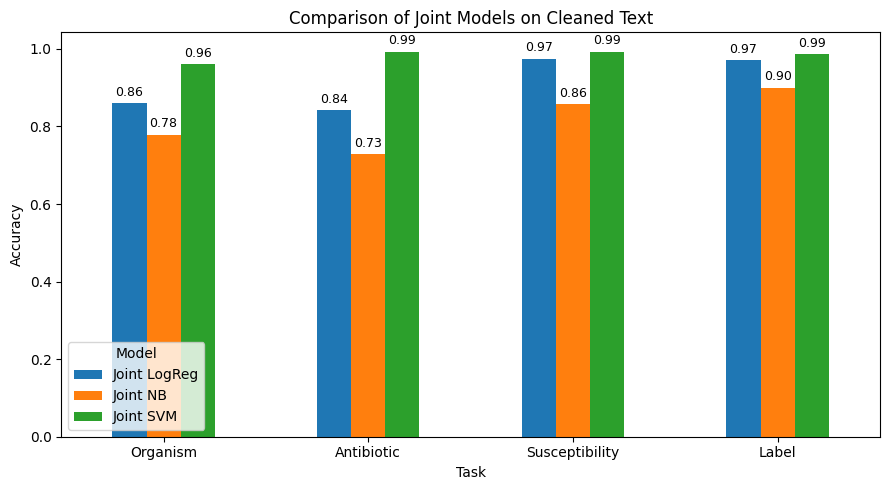

In [16]:
# graph comparing the 3 joint models accuracy
plot_pivot = joint_results_df.pivot(index="Task", columns="Model", values="Accuracy")

order = ["Organism", "Antibiotic", "Susceptibility", "Label"]
plot_pivot = plot_pivot.reindex(order)

ax = plot_pivot.plot(
    kind="bar",
    figsize=(9, 5),
)

plt.title("Comparison of Joint Models on Cleaned Text")
plt.ylabel("Accuracy")
plt.xlabel("Task")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=9, padding=3)

plt.legend(title="Model", loc="lower left")
plt.tight_layout()
plt.show()

In [17]:
#saving data set
joint_output_df = joined_df.copy()

# Logistic Regression
logreg_preds = joint_logreg_model.predict(joined_df["text_clean"])
joint_output_df["pred_org_joint_logreg"] = logreg_preds[:, 0]
joint_output_df["pred_abx_joint_logreg"] = logreg_preds[:, 1]
joint_output_df["pred_sus_joint_logreg"] = logreg_preds[:, 2]
joint_output_df["pred_label_joint_logreg"] = logreg_preds[:, 3]

# SVM
svm_preds = joint_svm_model.predict(joined_df["text_clean"])
joint_output_df["pred_org_joint_svm"] = svm_preds[:, 0]
joint_output_df["pred_abx_joint_svm"] = svm_preds[:, 1]
joint_output_df["pred_sus_joint_svm"] = svm_preds[:, 2]
joint_output_df["pred_label_joint_svm"] = svm_preds[:, 3]

# Naive Bayes
nb_preds = joint_nb_model.predict(joined_df["text_clean"])
joint_output_df["pred_org_joint_nb"] = nb_preds[:, 0]
joint_output_df["pred_abx_joint_nb"] = nb_preds[:, 1]
joint_output_df["pred_sus_joint_nb"] = nb_preds[:, 2]
joint_output_df["pred_label_joint_nb"] = nb_preds[:, 3]

joint_output_df.to_csv("joined_models.csv", index=False)

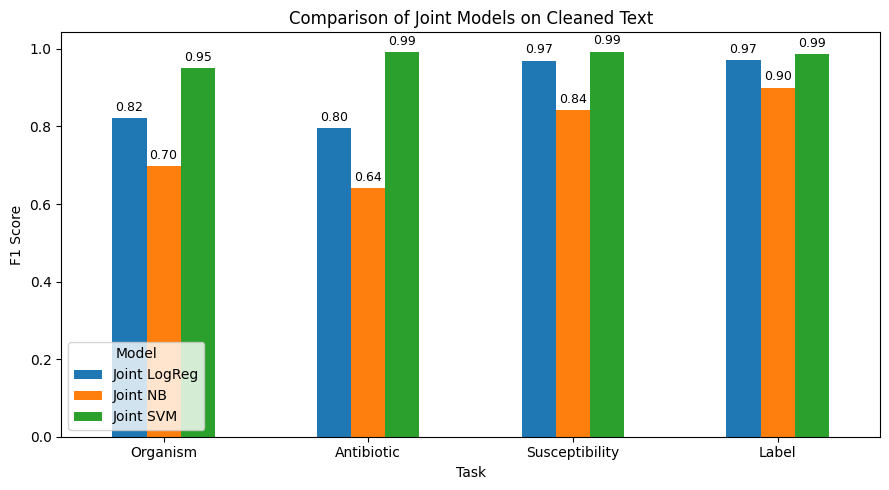

In [18]:
# graph comparing the 3 joint models
plot_pivot = joint_results_df.pivot(index="Task", columns="Model", values="F1")

order = ["Organism", "Antibiotic", "Susceptibility", "Label"]
plot_pivot = plot_pivot.reindex(order)

ax = plot_pivot.plot(
    kind="bar",
    figsize=(9, 5),
)

plt.title("Comparison of Joint Models on Cleaned Text")
plt.ylabel("F1 Score")
plt.xlabel("Task")
plt.xticks(rotation=0)

#adding labels to chart and shifting up so dont overlap
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=9, padding=3)

plt.legend(title="Model", loc="lower left")
plt.tight_layout()
plt.show()